In [1]:
import os
import pickle
import numpy as np
from tqdm.notebook import tqdm
import pydot
import graphviz
import tensorflow as tf
from nltk.translate.bleu_score import corpus_bleu
from tensorflow.keras.models import load_model
from tensorflow.keras.applications.vgg16 import VGG16, preprocess_input
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Model
from tensorflow.keras.utils import to_categorical, plot_model
from tensorflow.keras.layers import Input, Dense, LSTM, Embedding, Dropout, add

In [2]:
BASE_DIR="flickr8k"
WORKING_DIR="working"

In [3]:
# load vgg16 model
model = VGG16()
# restructure the model
model = Model(inputs=model.inputs, outputs=model.layers[-2].output)
# summarize
print(model.summary())

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv1 (Conv2D)                │ (None, 224, 224, 64)        │           1,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv2 (Conv2D)                │ (None, 224, 224, 64)        │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_pool (MaxPooling2D)           │ (None, 112, 112, 64)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv1 (Conv2D)                │ (None, 112, 112, 128)       │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv2 (Conv2D)                │ (None, 112, 112, 128)       │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_pool (MaxPooling2D)           │ (None, 56, 56, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv1 (Conv2D)                │ (None, 56, 56, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv2 (Conv2D)                │ (None, 56, 56, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv3 (Conv2D)                │ (None, 56, 56, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_pool (MaxPooling2D)           │ (None, 28, 28, 256)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv1 (Conv2D)                │ (None, 28, 28, 512)         │       1,180,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv2 (Conv2D)                │ (None, 28, 28, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv3 (Conv2D)                │ (None, 28, 28, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_pool (MaxPooling2D)           │ (None, 14, 14, 512)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv1 (Conv2D)                │ (None, 14, 14, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv2 (Conv2D)                │ (None, 14, 14, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv3 (Conv2D)                │ (None, 14, 14, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_pool (MaxPooling2D)           │ (None, 7, 7, 512)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 25088)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ fc1 (Dense)                          │ (None, 4096)                │     102,764,544 │
├──────────────────────────────────────┼─────────────────────────────┼──────────────

 Total params: 134,260,544 (512.16 MB)

 Trainable params: 134,260,544 (512.16 MB)

 Non-trainable params: 0 (0.00 B)

None


In [4]:
# load features from pickle
with open(os.path.join(WORKING_DIR, 'features.pkl'), 'rb') as f:
    features = pickle.load(f)

## Loading Captions 

In [5]:
with open(os.path.join(BASE_DIR, 'captions.txt'), 'r') as f:
    next(f)
    captions_doc = f.read()

In [6]:
# create mapping of image to captions
mapping = {}
# process lines
for line in tqdm(captions_doc.split('\n')):
    # split the line by comma(,)
    tokens = line.split(',')
    if len(line) < 2:
        continue
    image_id, caption = tokens[0], tokens[1:]
    # remove extension from image ID
    image_id = image_id.split('.')[0]
    # convert caption list to string
    caption = " ".join(caption)
    # create list if needed
    if image_id not in mapping:
        mapping[image_id] = []
    # store the caption
    mapping[image_id].append(caption)

  0%|          | 0/40456 [00:00<?, ?it/s]

In [7]:
len(mapping)

8091

## Preprocess text


In [8]:
def clean(mapping):
    for key, captions in mapping.items():
        for i in range(len(captions)):
            # take one caption at a time
            caption = captions[i]
            # preprocessing steps
            # convert to lowercase
            caption = caption.lower()
            # delete digits, special chars, etc., 
            caption = caption.replace('[^A-Za-z]', '')
            # delete additional spaces
            caption = caption.replace('\s+', ' ')
            # add start and end tags to the caption
            caption = 'startseq ' + " ".join([word for word in caption.split() if len(word)>1]) + ' endseq'
            captions[i] = caption

<>:12: SyntaxWarning: invalid escape sequence '\s'
<>:12: SyntaxWarning: invalid escape sequence '\s'
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_4768\822461702.py:12: SyntaxWarning: invalid escape sequence '\s'
  caption = caption.replace('\s+', ' ')


In [9]:
# before preprocess of text
mapping['1000268201_693b08cb0e']

['A child in a pink dress is climbing up a set of stairs in an entry way .',
 'A girl going into a wooden building .',
 'A little girl climbing into a wooden playhouse .',
 'A little girl climbing the stairs to her playhouse .',
 'A little girl in a pink dress going into a wooden cabin .']

In [10]:
# preprocess the text
clean(mapping)

In [11]:
# after preprocess of text
mapping['1000268201_693b08cb0e']

['startseq child in pink dress is climbing up set of stairs in an entry way endseq',
 'startseq girl going into wooden building endseq',
 'startseq little girl climbing into wooden playhouse endseq',
 'startseq little girl climbing the stairs to her playhouse endseq',
 'startseq little girl in pink dress going into wooden cabin endseq']

In [12]:
all_captions = []
for key in mapping:
    for caption in mapping[key]:
        all_captions.append(caption)

In [13]:
len(all_captions)

40455

In [14]:
all_captions[:10]

['startseq child in pink dress is climbing up set of stairs in an entry way endseq',
 'startseq girl going into wooden building endseq',
 'startseq little girl climbing into wooden playhouse endseq',
 'startseq little girl climbing the stairs to her playhouse endseq',
 'startseq little girl in pink dress going into wooden cabin endseq',
 'startseq black dog and spotted dog are fighting endseq',
 'startseq black dog and tri-colored dog playing with each other on the road endseq',
 'startseq black dog and white dog with brown spots are staring at each other in the street endseq',
 'startseq two dogs of different breeds looking at each other on the road endseq',
 'startseq two dogs on pavement moving toward each other endseq']

In [15]:
# tokenize the text
tokenizer = Tokenizer()
tokenizer.fit_on_texts(all_captions)
vocab_size = len(tokenizer.word_index) + 1

In [16]:
vocab_size

8485

In [17]:
# get maximum length of the caption available
max_length = max(len(caption.split()) for caption in all_captions)
max_length

35

## Train and test Split

In [18]:
image_ids = list(mapping.keys())
split = int(len(image_ids) * 0.90)
train = image_ids[:split]
test = image_ids[split:]

In [19]:
# create data generator to get data in batch (avoids session crash)
def data_generator(data_keys, mapping, features, tokenizer, max_length, vocab_size, batch_size):
    # loop over images
    X1, X2, y = list(), list(), list()
    n = 0
    while 1:
        for key in data_keys:
            n += 1
            captions = mapping[key]
            # process each caption
            for caption in captions:
                # encode the sequence
                seq = tokenizer.texts_to_sequences([caption])[0]
                # split the sequence into X, y pairs
                for i in range(1, len(seq)):
                    # split into input and output pairs
                    in_seq, out_seq = seq[:i], seq[i]
                    # pad input sequence
                    in_seq = pad_sequences([in_seq], maxlen=max_length)[0]
                    # encode output sequence
                    out_seq = to_categorical([out_seq], num_classes=vocab_size)[0]
                    
                    # store the sequences
                    X1.append(features[key][0])
                    X2.append(in_seq)
                    y.append(out_seq)
            if n == batch_size:
                X1, X2, y = np.array(X1), np.array(X2), np.array(y)
                yield [X1, X2], y
                X1, X2, y = list(), list(), list()
                n = 0

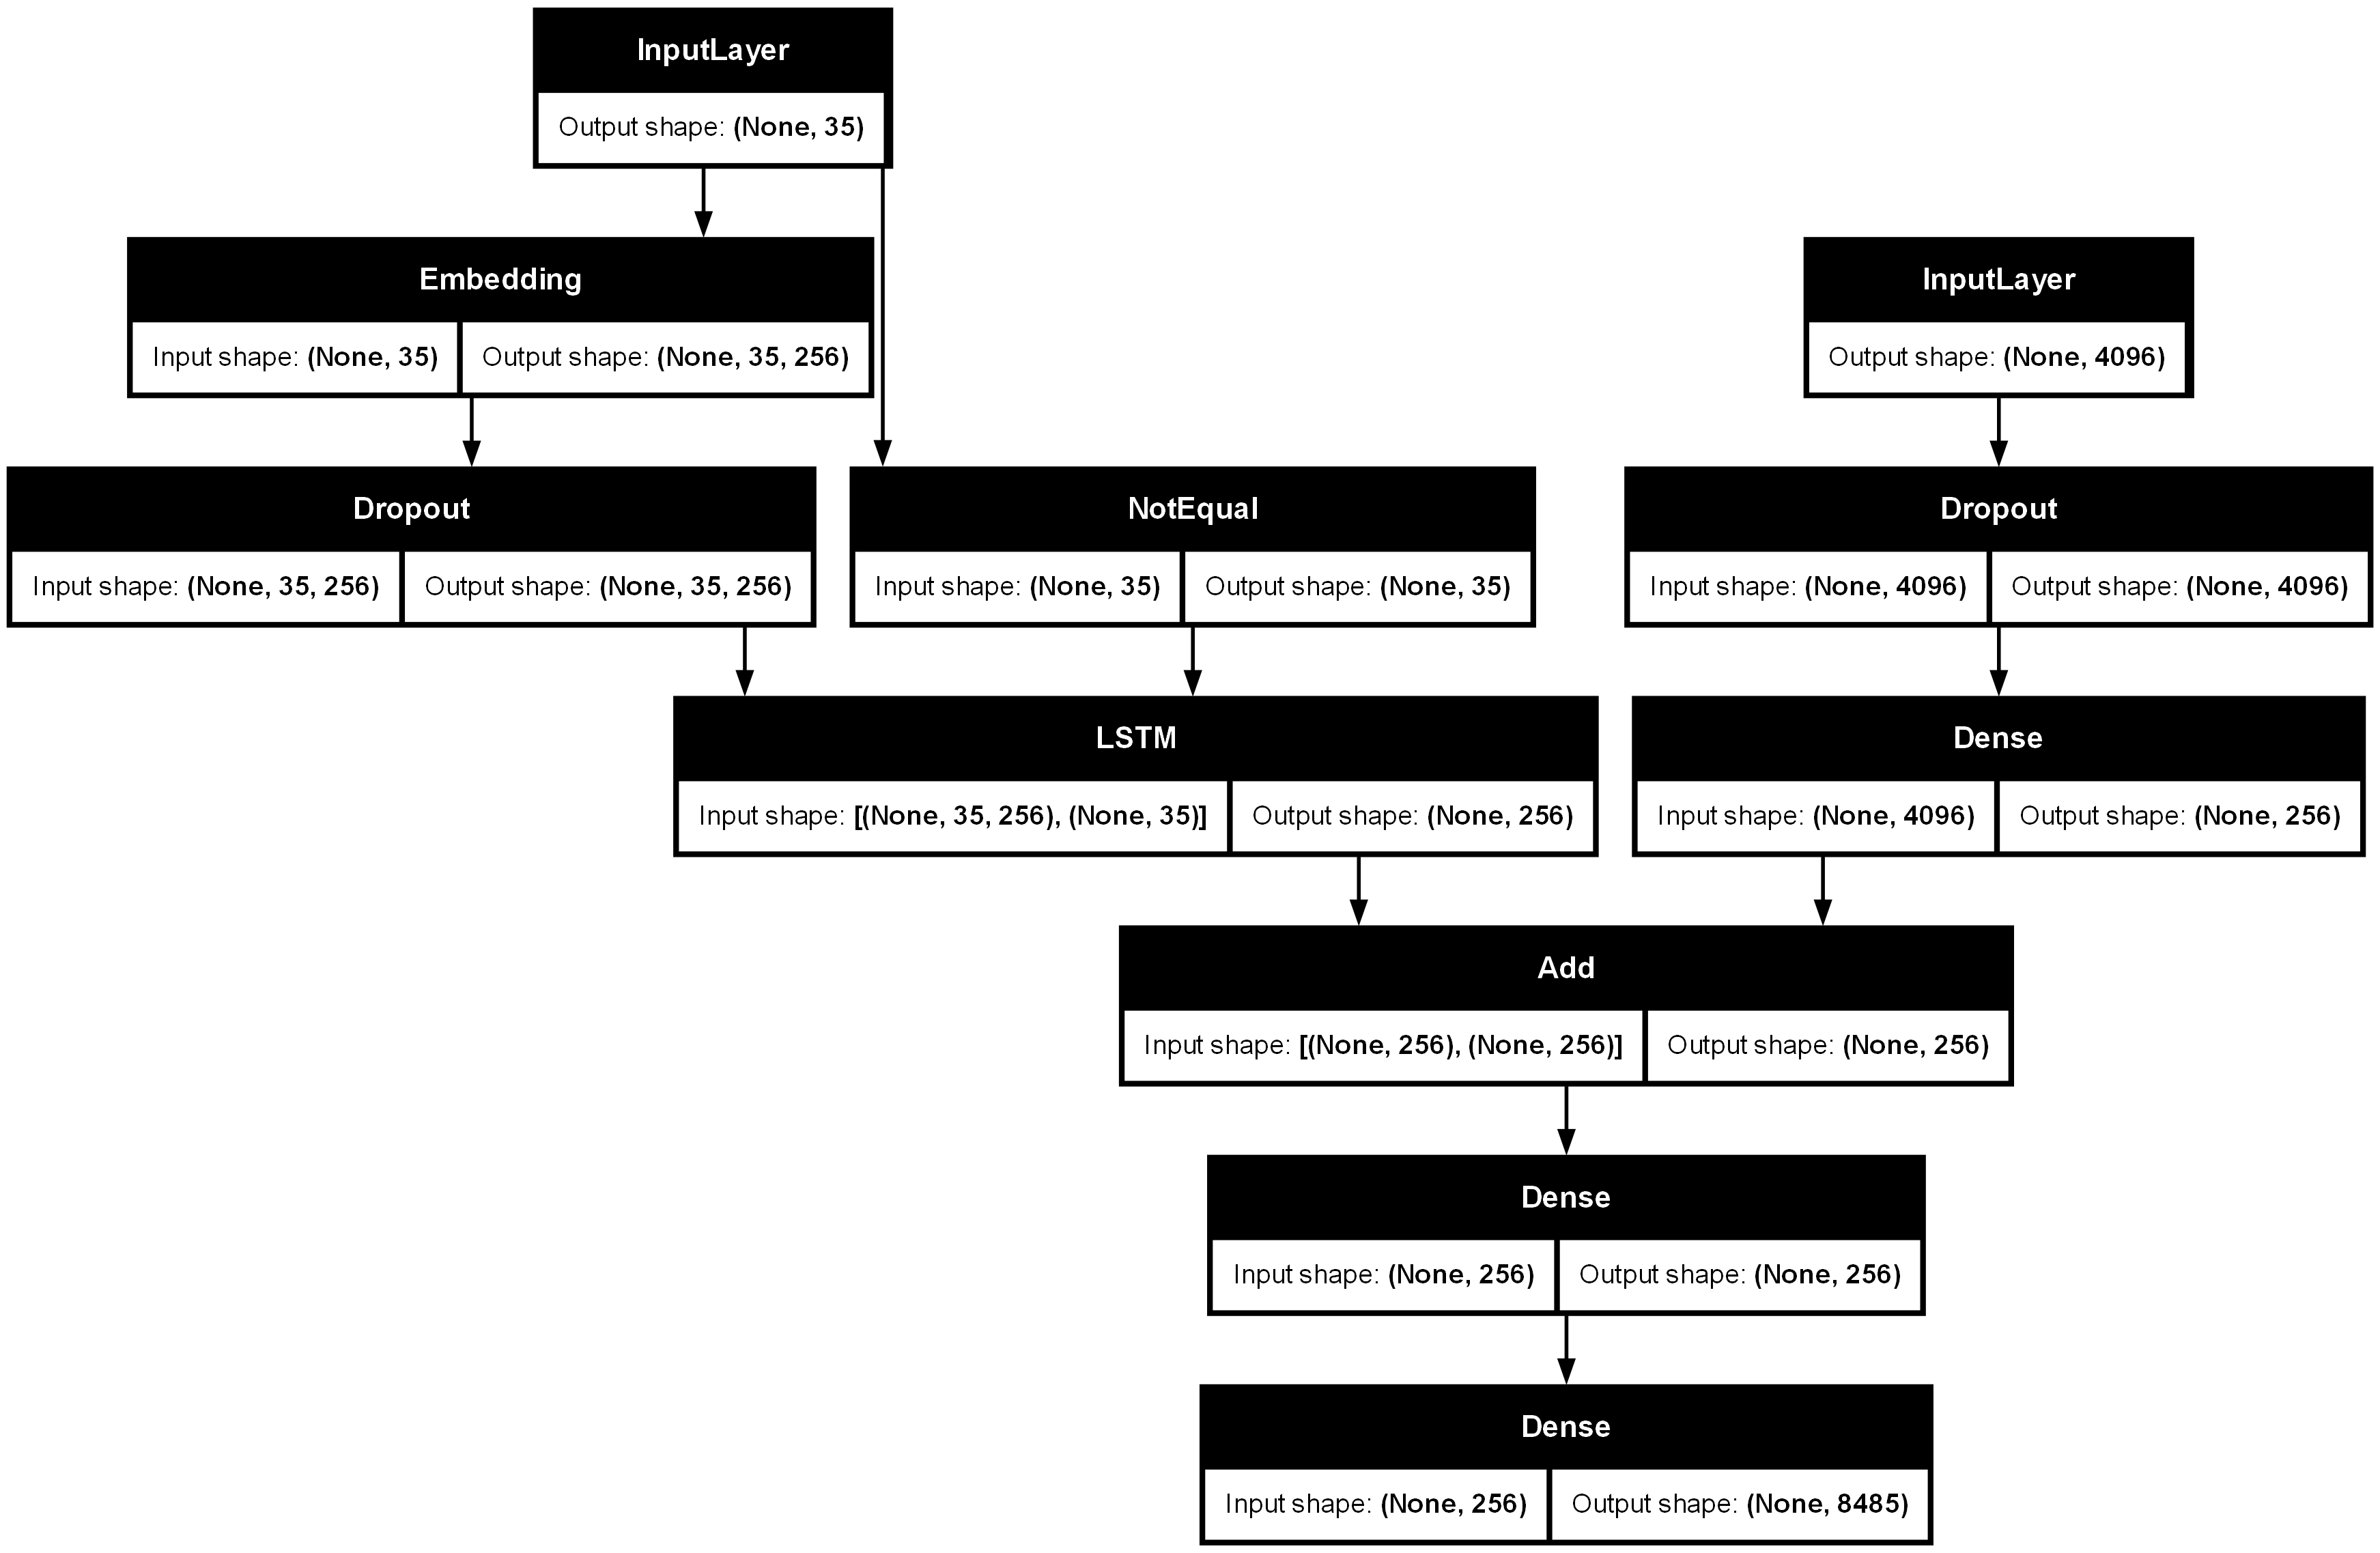

In [20]:
# encoder model
# image feature layers
inputs1 = Input(shape=(4096,))
fe1 = Dropout(0.4)(inputs1)
fe2 = Dense(256, activation='relu')(fe1)
# sequence feature layers
inputs2 = Input(shape=(max_length,))
se1 = Embedding(vocab_size, 256, mask_zero=True)(inputs2)
se2 = Dropout(0.4)(se1)
se3 = LSTM(256)(se2)

# decoder model
decoder1 = add([fe2, se3])
decoder2 = Dense(256, activation='relu')(decoder1)
outputs = Dense(vocab_size, activation='softmax')(decoder2)

model = Model(inputs=[inputs1, inputs2], outputs=outputs)
model.compile(loss='categorical_crossentropy', optimizer='adam')

# plot the model
plot_model(model, show_shapes=True)

## Load the model

In [25]:
model=tf.keras.models.load_model("newTrial.h5")

ValueError: Could not interpret initializer identifier: {'module': 'keras.initializers', 'class_name': 'Orthogonal', 'config': {'gain': 1.0, 'seed': None}, 'registered_name': None}

In [22]:
model.summary()

Model: "model_1"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_3 (InputLayer)           [(None, 35)]         0           []                               
                                                                                                  
 input_2 (InputLayer)           [(None, 4096)]       0           []                               
                                                                                                  
 embedding (Embedding)          (None, 35, 256)      2172160     ['input_3[0][0]']                
                                                                                                  
 dropout (Dropout)              (None, 4096)         0           ['input_2[0][0]']                
                                                                                            

## Generating Captions

In [23]:
def idx_to_word(integer, tokenizer):
    for word, index in tokenizer.word_index.items():
        if index == integer:
            return word
    return None

In [24]:
# generate caption for an image
def predict_caption(model, image, tokenizer, max_length):
    # add start tag for generation process
    in_text = 'startseq'
    # iterate over the max length of sequence
    for i in range(max_length):
        # encode input sequence
        sequence = tokenizer.texts_to_sequences([in_text])[0]
        # pad the sequence
        sequence = pad_sequences([sequence], max_length)
        # predict next word
        yhat = model.predict([image, sequence], verbose=0)
        # get index with high probability
        yhat = np.argmax(yhat)
        # convert index to word
        word = idx_to_word(yhat, tokenizer)
        # stop if word not found
        if word is None:
            break
        # append word as input for generating next word
        in_text += " " + word
        # stop if we reach end tag
        if word == 'endseq':
            break
      
    return in_text

# BLUE SCORE

In [25]:
from nltk.translate.bleu_score import corpus_bleu
# validate with test data
actual, predicted = list(), list()

for key in tqdm(test):
    # get actual caption
    captions = mapping[key]
    # predict the caption for image
    y_pred = predict_caption(model, features[key], tokenizer, max_length) 
    # split into words
    actual_captions = [caption.split() for caption in captions]
    y_pred = y_pred.split()
    # append to the list
    actual.append(actual_captions)
    predicted.append(y_pred)
    
# calcuate BLEU score
print("BLEU-1: %f" % corpus_bleu(actual, predicted, weights=(1.0, 0, 0, 0)))
print("BLEU-2: %f" % corpus_bleu(actual, predicted, weights=(0.5, 0.5, 0, 0)))

  0%|          | 0/810 [00:00<?, ?it/s]

BLEU-1: 0.527954
BLEU-2: 0.303033


## Generating Captions

In [25]:
from PIL import Image
import matplotlib.pyplot as plt
def generate_caption(image_name):
    # load the image
    # image_name = "1001773457_577c3a7d70.jpg"
    image_id = image_name.split('.')[0]
    img_path = os.path.join(BASE_DIR, "Images", image_name)
    image = Image.open(img_path)
    captions = mapping[image_id]
    print('---------------------Actual---------------------')
    for caption in captions:
        print(caption)
    # predict the caption
    y_pred = predict_caption(model, features[image_id], tokenizer, max_length)
    print('--------------------Predicted--------------------')
    print(y_pred)
    plt.imshow(image)

---------------------Actual---------------------
startseq little girl covered in paint sits in front of painted rainbow with her hands in bowl endseq
startseq little girl is sitting in front of large painted rainbow endseq
startseq small girl in the grass plays with fingerpaints in front of white canvas with rainbow on it endseq
startseq there is girl with pigtails sitting in front of rainbow painting endseq
startseq young girl with pigtails painting outside in the grass endseq
--------------------Predicted--------------------
startseq little girl in pink dress is sitting in front of hay covered rainbow endseq


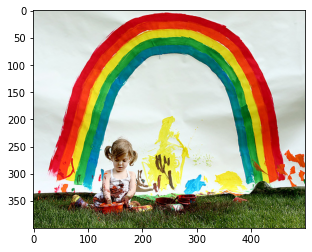

In [26]:
generate_caption("1002674143_1b742ab4b8.jpg")

---------------------Actual---------------------
startseq kayaker kayaks through the water endseq
startseq person kayaking in the ocean endseq
startseq person kayaks in the middle of the ocean on grey day endseq
startseq person rows boat over large body of water endseq
startseq person in boat with paddle in hand endseq
--------------------Predicted--------------------
startseq man rows boat endseq


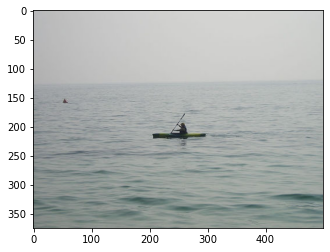

In [37]:
generate_caption("19212715_20476497a3.jpg")

# NEW CODE DATED 05/03/2024

In [27]:
vgg_model = VGG16()
# restructure the model
vgg_model = Model(inputs=vgg_model.inputs, outputs=vgg_model.layers[-2].output)

In [28]:
image_path ='E:\cat_image.jpg'
# load image
image = load_img(image_path, target_size=(224, 224))
# convert image pixels to numpy array
image = img_to_array(image)
# reshape data for model
image = image.reshape((1, image.shape[0], image.shape[1], image.shape[2]))
# preprocess image for vgg
image = preprocess_input(image)
# extract features
feature = vgg_model.predict(image, verbose=0)
# predict from the trained model
predict_caption(model, feature, tokenizer, max_length)

'startseq dog is looking at something in the air endseq'

## Video To Frames


In [29]:
import cv2
import os

In [30]:
# Function to extract frames from a video
def extract_frames(video_path, output_folder):
    # Open the video file
    cap = cv2.VideoCapture(video_path)
    
    # Check if the video file was opened successfully
    if not cap.isOpened():
        print("Error: Could not open video.")
        return
    
    # Create the output folder if it doesn't exist
    os.makedirs(output_folder, exist_ok=True)
    
    # Initialize frame count and time variable
    frame_count = 0
    time = 0
    
    # Read until video is completed
    while cap.isOpened():
        # Capture frame-by-frame
        ret, frame = cap.read()
        
        # Check if frame is read correctly
        if ret:
            # Increment frame count
            frame_count += 1
            
            # Save frame to file
            image_path = os.path.join(output_folder, f"img{frame_count}.jpg")
            cv2.imwrite(image_path, frame)
            
            # Print progress
#             print(f"Frame {frame_count} saved as {image_path}")
            
            # Jump to next second (1000 milliseconds)
            time += 1000
            cap.set(cv2.CAP_PROP_POS_MSEC, time)
        else:
            break
    
    # Release the video capture object and close the output folder
    cap.release()
    cv2.destroyAllWindows()

In [64]:
# Path to the input video
video_path = 'cutting_cumber_9.avi'

# Output folder for saving images
output_folder = 'output_images'

# Call the function to extract frames from the video
extract_frames(video_path, output_folder)

## Function for creating captions for Frames

In [65]:
folder_path = 'output_images/'
files = os.listdir(folder_path)
arr=[]
# i=0
for file in files:
#     print(len(file))
#     print(file)
    if file.endswith('.jpg') or file.endswith('.bmp') or file.endswith('.png'):
        new_str=folder_path+file
        image = load_img(new_str, target_size=(224, 224))
        image = img_to_array(image)
        image = image.reshape((1, image.shape[0], image.shape[1], image.shape[2]))
        image = preprocess_input(image)
        feature = vgg_model.predict(image, verbose=0)
        new_str=predict_caption(model, feature, tokenizer, max_length)
        print(new_str)
        arr.append(new_str)

startseq young boy is climbing up large green object endseq
startseq man is climbing his head on the edge of concrete wall endseq
startseq the little boy is wearing green shirt and is jumping off the wall endseq
startseq young boy is riding bike in the air endseq
startseq small baby with long hair is looking at something in the air endseq
startseq little boy is eating piece of large flower endseq
startseq little girl in blue shirt is climbing up the side of the water endseq
startseq baby in green shirt is climbing up the stones endseq


In [53]:
arr

['startseq man in white shirt and white wal mart stage endseq',
 'startseq man in white shirt and white shirt is playing guitar endseq',
 'startseq man in white shirt and white shirt is playing guitar endseq',
 'startseq man in white shirt and white shirt is playing guitar endseq',
 'startseq man in white shirt and white shirt is playing guitar endseq',
 'startseq man in white shirt and white shirt is playing guitar endseq',
 'startseq man in white shirt and hat plays guitar endseq']

In [54]:
string_to_remove = 'startseq'
# Remove the string from the array
modified_array = [string.replace(string_to_remove, '') for string in arr]
string_to_remove = 'endseq'
modified_array = [string.replace(string_to_remove, '') for string in modified_array]

In [55]:
print(modified_array)

[' man in white shirt and white wal mart stage ', ' man in white shirt and white shirt is playing guitar ', ' man in white shirt and white shirt is playing guitar ', ' man in white shirt and white shirt is playing guitar ', ' man in white shirt and white shirt is playing guitar ', ' man in white shirt and white shirt is playing guitar ', ' man in white shirt and hat plays guitar ']


## Mearge all to one string and summarize


In [56]:
merged_string = ''.join(modified_array)

In [1]:
arr='man in white shirt and white wal mart stage  man in white shirt and white shirt is playing guitar'

In [2]:
# Function to identify subject in a sentence
def identify_subject(sentence):
    # Simple heuristic: the subject is the first noun phrase
    # More advanced NLP techniques can be used for better results
    tokens = sentence.split()
    for i, token in enumerate(tokens):
        if token.lower() in ['man', 'woman', 'boy', 'girl']:  # Extend this list as needed
            return ' '.join(tokens[:i+1])
    return ''

# Merge sentences based on the subject
def merge_sentences(captions):
    subject_dict = {}
    for caption in captions:
        subject = identify_subject(caption)
        if subject:
            if subject in subject_dict:
                subject_dict[subject] += ' ' + ' '.join(caption.split()[len(subject.split()):])
            else:
                subject_dict[subject] = caption
        else:
            subject_dict[caption] = caption

    merged_captions = ' '.join(subject_dict.values())
    return merged_captions

merged_string = merge_sentences(arr)
print(merged_string)

m a n   i w h t e s r d l g p y u


In [3]:
def merge_captions(captions):
    modified_captions = []
    for caption in captions:
        sentences = caption.split(' ') # Split caption into words
        subject = ''  # Initialize subject
        sentence = []  # Initialize sentence
        for word in sentences:
            if word.lower() in ['man', 'woman']: # Check for subject
                subject = word
                sentence.append(word)
            else:
                sentence.append(word)
        # Append the rest of the sentence
        modified_captions.append(' '.join(sentence))
    
    return modified_captions


In [4]:
modified_captions = merge_captions(arr)

In [5]:
modified_captions

['m',
 'a',
 'n',
 ' ',
 'i',
 'n',
 ' ',
 'w',
 'h',
 'i',
 't',
 'e',
 ' ',
 's',
 'h',
 'i',
 'r',
 't',
 ' ',
 'a',
 'n',
 'd',
 ' ',
 'w',
 'h',
 'i',
 't',
 'e',
 ' ',
 'w',
 'a',
 'l',
 ' ',
 'm',
 'a',
 'r',
 't',
 ' ',
 's',
 't',
 'a',
 'g',
 'e',
 ' ',
 ' ',
 'm',
 'a',
 'n',
 ' ',
 'i',
 'n',
 ' ',
 'w',
 'h',
 'i',
 't',
 'e',
 ' ',
 's',
 'h',
 'i',
 'r',
 't',
 ' ',
 'a',
 'n',
 'd',
 ' ',
 'w',
 'h',
 'i',
 't',
 'e',
 ' ',
 's',
 'h',
 'i',
 'r',
 't',
 ' ',
 'i',
 's',
 ' ',
 'p',
 'l',
 'a',
 'y',
 'i',
 'n',
 'g',
 ' ',
 'g',
 'u',
 'i',
 't',
 'a',
 'r']

# Mearged String to a meaning full Text


In [50]:
import torch
from transformers import T5Tokenizer, T5ForConditionalGeneration, T5Config


In [51]:
model_text = T5ForConditionalGeneration.from_pretrained('t5-small')
tokenizer_text = T5Tokenizer.from_pretrained('t5-small')
device = torch.device('cpu')
     

You are using the default legacy behaviour of the <class 'transformers.models.t5.tokenization_t5.T5Tokenizer'>. This is expected, and simply means that the `legacy` (previous) behavior will be used so nothing changes for you. If you want to use the new behaviour, set `legacy=False`. This should only be set if you understand what it means, and thoroughly read the reason why this was added as explained in https://github.com/huggingface/transformers/pull/24565
Special tokens have been added in the vocabulary, make sure the associated word embeddings are fine-tuned or trained.


In [52]:
preprocessed_text = text.strip().replace('\n','')
t5_input_text = 'summarize: ' + preprocessed_text

In [53]:
t5_input_text

'summarize: man in yellow shirt is playing baseball  three players struggling for the ball  man in yellow shirt and black pants is standing on the grass with crowd in the background  crowd of people watch the crowd  crowd of people are playing game of an crowd  crowd of people playing soccer  crowd of people are playing football on field  group of people are playing football in front of building  man in yellow shirt kicks the ball while crowd watches  group of people playing soccer on the field  group of people playing game at park park  man is sitting on bench in front of an urban setting  crowd of people are playing game of an event  crowd of people watch the crowd watching the crowd  crowd of people are playing game of water  crowd of people are playing football on field  crowd of people are playing football on field  crowd of people are playing football  crowd of people are playing football  crowd of people are playing football'

In [54]:
len(t5_input_text.split())

166

In [55]:
tokenized_text = tokenizer_text.encode(t5_input_text, return_tensors='pt', max_length=512).to(device)

Truncation was not explicitly activated but `max_length` is provided a specific value, please use `truncation=True` to explicitly truncate examples to max length. Defaulting to 'longest_first' truncation strategy. If you encode pairs of sequences (GLUE-style) with the tokenizer you can select this strategy more precisely by providing a specific strategy to `truncation`.


In [58]:
summary_ids = model_text.generate(tokenized_text, min_length=10, max_length=15)
summary = tokenizer_text.decode(summary_ids[0], skip_special_tokens=True)

In [59]:
summary

'man in yellow shirt is playing baseball three players struggling for the ball man'

In [44]:
text=' two men are standing in front of the wall  the man is wearing black shirt and playing Piano is standing on the dancefloor  man in black shirt is standing on the side of the side of the wall  man in black shirt is standing on platform  man in black shirt is looking at the camera  two women in dark room are playing with one another  man in black shirt is standing on the side of the wall  man in black hat is standing on the sidewalk  the man is wearing black shirt and is standing on the bed  the man is wearing black shirt and is standing on platform  the man is wearing black shirt and is standing on the side of the stairs  the man is wearing black shirt and is standing on the dancefloor  the man is wearing black shirt and is standing on the dancefloor '

In [39]:
text

' two men are standing in front of the wall  the man is wearing black shirt and is standing on the dancefloor  man in black shirt is standing on the side of the side of the wall  man in black shirt is standing on platform  man in black shirt is looking at the camera  two women in dark room are playing with one another  man in black shirt is standing on the side of the wall  man in black hat is standing on the sidewalk  the man is wearing black shirt and is standing on the bed  the man is wearing black shirt and is standing on platform  the man is wearing black shirt and is standing on the side of the stairs  the man is wearing black shirt and is standing on the dancefloor  the man is wearing black shirt and is standing on the dancefloor '

# Latent Semantic Analysis

In [49]:
text

' two men are standing in front of the wall  the man is wearing black shirt and playing Piano is standing on the dancefloor  man in black shirt is standing on the side of the side of the wall  man in black shirt is standing on platform  man in black shirt is looking at the camera  two women in dark room are playing with one another  man in black shirt is standing on the side of the wall  man in black hat is standing on the sidewalk  the man is wearing black shirt and is standing on the bed  the man is wearing black shirt and is standing on platform  the man is wearing black shirt and is standing on the side of the stairs  the man is wearing black shirt and is standing on the dancefloor  the man is wearing black shirt and is standing on the dancefloor '

In [62]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from bs4 import BeautifulSoup
import nltk
from nltk.corpus import stopwords

In [63]:
import numpy as np

In [65]:
# Initialize a TF-IDF Vectorizer
tfidf_vectorizer = TfidfVectorizer(stop_words='english')

# Fit and transform the paragraph
tfidf_matrix = tfidf_vectorizer.fit_transform([text])

# Apply Latent Semantic Analysis (LSA) using TruncatedSVD
num_topics = 2  # Number of topics to extract
lsa_model = TruncatedSVD(n_components=num_topics)
lsa_topic_matrix = lsa_model.fit_transform(tfidf_matrix)

# Get the feature names from TF-IDF vectorizer
feature_names = tfidf_vectorizer.get_feature_names()

# Initialize a list to store topics
lsa_topics = []

# Store each word in a separate array at different indices
for i, topic in enumerate(lsa_model.components_):
    top_terms_idx = topic.argsort()[:-20:-1]  # Get top 10 terms for each topic
    top_terms = [feature_names[idx] for idx in top_terms_idx]
    lsa_topics.extend([[term] for term in top_terms])

# Print the list of topics
print("LSA Topics:")
print(lsa_topics)


LSA Topics:
[['crowd'], ['people'], ['playing'], ['football'], ['game'], ['man'], ['field'], ['yellow'], ['shirt'], ['group'], ['soccer'], ['park'], ['watch'], ['ball'], ['grass'], ['event'], ['building'], ['black'], ['bench']]


In [38]:
lsa_topics[1]

['man']

In [69]:
import random

# Given array of LSA topics
lsa_topics = [['crowd'], ['people'], ['playing'], ['football'], ['game'], ['man'], ['field'], ['yellow'], ['shirt'], ['group'], ['soccer'], ['park'], ['watch'], ['ball'], ['grass'], ['event'], ['building'], ['black'], ['bench']]

# Randomly select words from the LSA topics
sentence_words = [random.choice(topic) for topic in lsa_topics]

# Constructing the meaningful sentence
meaningful_sentence = ' '.join(sentence_words) + '.'

print(meaningful_sentence.capitalize())

Crowd people playing football game man field yellow shirt group soccer park watch ball grass event building black bench.


In [9]:
descriptions = ['woman in black shirt and glasses is looking at the camera',
                'woman in traditional clothes is looking at something in the distance',
                'two men are standing in front of wall',
                'man in black shirt and black shorts is standing in front of the wall',
                'man in black shirt and gold scarf is standing in front of an older man',
                'man in black shirt is standing in front of an event',
                'man in black and green outfit is having big picture of man in black shirt',
                'man in black and black outfit is having drink while participating in parade',
                'man in traditional clothing is looking at the camera',
                'man in black jacket is looking at the camera while another man looks at her']

In [70]:
from sklearn.metrics.pairwise import cosine_similarity


In [71]:
# Preprocessing and vectorizing the descriptions
vectorizer = TfidfVectorizer(stop_words='english')
X = vectorizer.fit_transform(modified_array)

# Dimensionality reduction using TruncatedSVD (LSA)
lsa_model = TruncatedSVD(n_components=2)
X_lsa = lsa_model.fit_transform(X)

# Calculate cosine similarity between all pairs of descriptions
similarity_matrix = cosine_similarity(X_lsa)

# Find the indices of the pair with the highest similarity
max_similarity_index = similarity_matrix.argmax()
row_index = max_similarity_index // similarity_matrix.shape[1]
col_index = max_similarity_index % similarity_matrix.shape[1]

# Constructing the meaningful sentence
meaningful_sentence = descriptions[row_index] + ' ' + descriptions[col_index]

print(meaningful_sentence.capitalize())


Man in black shirt is standing in front of an event man in black shirt is standing in front of an event


In [78]:
import nltk
from nltk.tokenize import sent_tokenize, word_tokenize
from collections import defaultdict
from heapq import nlargest

In [79]:
text = 'man in yellow shirt is playing baseball three players struggling for the ball man in yellow shirt and black pants is standing on the grass with crowd in the background crowd of people watch the crowd crowd of people are playing game of an crowd crowd of people playing soccer crowd of people are playing football on field group of people are playing football in front of building man in yellow shirt kicks the ball while crowd watches group of people playing soccer on the field group of people playing game at park park man is sitting on bench in front of an urban setting crowd of people are playing game of an event crowd of people watch the crowd watching the crowd crowd of people are playing game of water crowd of people are playing football on field crowd of people are playing football on field crowd of people are playing football crowd of people are playing football crowd of people are playing football'

# Tokenize the text into sentences
sentences = sent_tokenize(text)

# Tokenize the text into words
words = word_tokenize(text)

# Calculate word frequencies
word_freq = nltk.FreqDist(words)

# Initialize dictionary to store scores for each sentence
sentence_scores = defaultdict(int)

# Calculate scores for each sentence based on word frequencies
for sentence in sentences:
    for word in word_tokenize(sentence):
        if word in word_freq:
            sentence_scores[sentence] += word_freq[word]

# Get the top 5 sentences with highest scores
summary_sentences = nlargest(5, sentence_scores, key=sentence_scores.get)

# Print the summary
summary = ' '.join(summary_sentences)
print(summary)

man in yellow shirt is playing baseball three players struggling for the ball man in yellow shirt and black pants is standing on the grass with crowd in the background crowd of people watch the crowd crowd of people are playing game of an crowd crowd of people playing soccer crowd of people are playing football on field group of people are playing football in front of building man in yellow shirt kicks the ball while crowd watches group of people playing soccer on the field group of people playing game at park park man is sitting on bench in front of an urban setting crowd of people are playing game of an event crowd of people watch the crowd watching the crowd crowd of people are playing game of water crowd of people are playing football on field crowd of people are playing football on field crowd of people are playing football crowd of people are playing football crowd of people are playing football


In [47]:
import nltk
from nltk.translate.bleu_score import sentence_bleu

In [59]:
def calculate_bleu(reference_text, candidate_text):
    # Tokenize reference and candidate texts
    reference_tokens = nltk.word_tokenize(reference_text.lower())
    candidate_tokens = nltk.word_tokenize(candidate_text.lower())

    # Calculate BLEU score
    bleu_score = sentence_bleu([reference_tokens], candidate_tokens)
    return bleu_score

# Reference and candidate texts
reference_text =Guitar
candidate_text =text

# Calculate BLEU score
bleu_score = calculate_bleu(reference_text, candidate_text)
print("BLEU Score:", bleu_score)

BLEU Score: 6.573430125233297e-79


C:\Users\Aditya\anaconda3\lib\site-packages\nltk\translate\bleu_score.py:516: UserWarning: 
The hypothesis contains 0 counts of 4-gram overlaps.
Therefore the BLEU score evaluates to 0, independently of
how many N-gram overlaps of lower order it contains.
Consider using lower n-gram order or use SmoothingFunction()
  warnings.warn(_msg)


In [62]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

def cosine_similarity_sentences(sentence1, sentence2):
    # Initialize TF-IDF vectorizer
    vectorizer = TfidfVectorizer()

    # Fit and transform the sentences
    vectors = vectorizer.fit_transform([sentence1, sentence2])

    # Calculate cosine similarity
    similarity = cosine_similarity(vectors)

    return similarity[0, 1]  # Return cosine similarity between the two sentences

# Example usage:
sentence1=Guitar
sentence2 = text
similarity = cosine_similarity_sentences(sentence1, sentence2)
print("Cosine Similarity:", similarity)

Cosine Similarity: 0.39392528554942596


In [111]:
string='''a man is cutting a piece of paper in half lengthwise using scissors a man cuts a piece of paper a man is cutting a piece of paper a man is cutting a paper by scissor a man is cutting paper a man is cutting a piece of paper a man is cutting paper a man is cutting some paper a man is cutting a piece of paper a guy cuts paper a man is cutting a piece of paper the man cut a piece of paper in half the man is using scissors to cut paper a man is cutting paper into two equal strips a man cuts some paper the man cut a piece of paper the man cut the paper with sissors a man is cutting a piece of paper in half a person doing something a man is cutting shapes out of paper
one man cutting paper with scissor the man is cutting the paper with scissor a man is cutting a paper a man is cutting paper the person is cutting paper man cutting paper
cuting pepars a man is cutting a piece of paper a man is cutting the paper the man cut the paper along the fold the man is cutting paper a man is cutting a paper with a scissors'''


In [112]:
string

'a man is cutting a piece of paper in half lengthwise using scissors a man cuts a piece of paper a man is cutting a piece of paper a man is cutting a paper by scissor a man is cutting paper a man is cutting a piece of paper a man is cutting paper a man is cutting some paper a man is cutting a piece of paper a guy cuts paper a man is cutting a piece of paper the man cut a piece of paper in half the man is using scissors to cut paper a man is cutting paper into two equal strips a man cuts some paper the man cut a piece of paper the man cut the paper with sissors a man is cutting a piece of paper in half a person doing something a man is cutting shapes out of paper\none man cutting paper with scissor the man is cutting the paper with scissor a man is cutting a paper a man is cutting paper the person is cutting paper man cutting paper\ncuting pepars a man is cutting a piece of paper a man is cutting the paper the man cut the paper along the fold the man is cutting paper a man is cutting a 

**# Actual Captions ***

In [63]:
Cooking='Knife cutting vegetables'

In [61]:
Guitar='''a young man is seated and playing a guitar
a man is playing a guitar
a man is playing a guitar
'''

In [42]:
Man_Piano='''a man is playing the piano
a man is playing a piano
a man is playing a piano
a man is playing piano
a man is playing piano
a man is playing piano
a man is playing piano
a man is playing the piano
a man is playing the piano
a man is playing the piano
a man performing on a piano
a man plays the piano
a mand played on a white piano
the man is playing the piano
the man played the piano
a man is playing a white grand piano
a guy is playing the piano
the man is playing the piano
a man is playing the piano
a man is playing the piano
a man is playing a white piano
a man is playing on a piano
the man is playing music on the piano
a man is playing the piano
a man playing piano 
'''